# Conditional Generator Matching on toys

The `cgm_loss`, the Conditional Generator Matching loss, is keyed by a Bregman divergence and applied per generator component. Its default for an Ito operator is squared-$L_2$ (plain MSE). On the other hand, the masking CTMC is a discrete pure-jump generator (`CTMCGeneratorOperator` + `MaskingInterpolant` + `TauLeapingSampler`) trained with the KL / cross-entropy Bregman divergence, the natural choice on the probability simplex.

We use the same `TwoMoons` toy for both: directly for the continuous Ito flow, and on a quantised grid for the discrete CTMC.

ToyDataset(n=4000, d=2, labels={0, 1}, meta={'noise': 0.08})


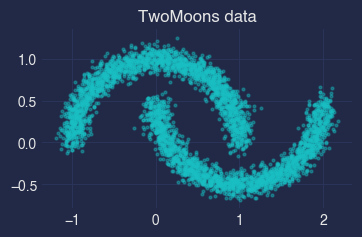

In [ ]:
import torch
import matplotlib.pyplot as plt
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-dark.mplstyle')

import nami
from nami_toys import TwoMoons, make_generator

torch.manual_seed(0)
gen = make_generator(0)

data = TwoMoons(noise=0.08).generate(4000, generator=gen)
X = data.x  # (N, 2)
print(data)

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(X[:, 0], X[:, 1], s=4, alpha=0.4)
ax.set_aspect("equal")
plt.show()

### Ito flow with `cgm_loss` (squared-$L_2$ Bregman)

We parameterise a drift-only Ito generator (an ODE) and train it with `cgm_loss`. With `divergence=None` the operator supplies its canonical Bregman divergence; squared-$L_2$ for Itô. So, for a drift-only generator this is
exactly the usual flow-matching MSE, now expressed through the CGM interface.

In [2]:
op = nami.ItoGeneratorOperator(event_shape=(2,), diffusion="none")
field = nami.GeneratorField(2, operator=op, hidden=256, layers=6)
interp = nami.LinearInterpolant()
param = nami.generator_prediction(op)
opt = torch.optim.Adam(field.parameters(), lr=2e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=10_000)

for step in range(4000):
    idx = torch.randint(0, len(X), (256,))
    x_data = X[idx]
    x_noise = torch.randn_like(x_data)
    loss = nami.cgm_loss(
        field,
        x_noise=x_noise, x_data=x_data,
        interpolant=interp,
        parameterization=param,   # divergence=None -> SquaredL2
    )
    opt.zero_grad(); loss.backward(); opt.step(); scheduler.step()
    if step % 300 == 0:
        print(f"step {step:4d}  cgm_loss {loss.item():.4f}  lr {scheduler.get_last_lr()[0]:.4e}")
print(f"final     cgm_loss {loss.item():.4f}")

step    0  cgm_loss 1.7055  lr 2.0000e-03
step  300  cgm_loss 1.0944  lr 1.9955e-03
step  600  cgm_loss 1.1826  lr 1.9822e-03
step  900  cgm_loss 1.0628  lr 1.9602e-03
step 1200  cgm_loss 0.9652  lr 1.9297e-03
step 1500  cgm_loss 1.0319  lr 1.8909e-03
step 1800  cgm_loss 0.9827  lr 1.8442e-03
step 2100  cgm_loss 0.9987  lr 1.7900e-03
step 2400  cgm_loss 1.0119  lr 1.7288e-03
step 2700  cgm_loss 0.9938  lr 1.6611e-03
step 3000  cgm_loss 0.9420  lr 1.5875e-03
step 3300  cgm_loss 0.9307  lr 1.5088e-03
step 3600  cgm_loss 0.8788  lr 1.4255e-03
step 3900  cgm_loss 1.1071  lr 1.3384e-03
final     cgm_loss 0.9921


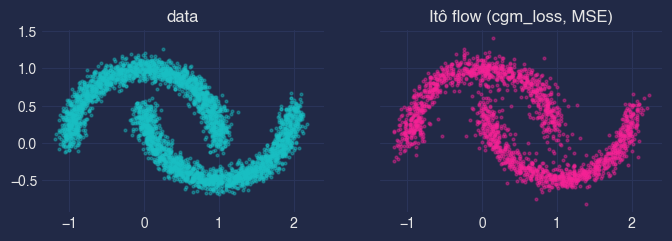

In [3]:
flow = nami.GeneratorMatching(
    field, nami.RK4(steps=50), parameterization=param, event_shape=(2,),
)
with torch.no_grad():
    samples = flow().sample((2000,))

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
axes[0].scatter(X[:, 0], X[:, 1], s=4, alpha=0.4)
axes[0].set_title("data")
axes[1].scatter(samples[:, 0], samples[:, 1], s=4, alpha=0.4, color="C1")
axes[1].set_title("Itô flow (cgm_loss, MSE)")
for a in axes:
    a.set_aspect("equal")
plt.show()

### Masking CTMC with the KL Bregman divergence

A pure-jump generator lives on a discrete state space, so we quantise each coordinate onto a `K`-bin grid -> integer tokens. The `CTMCGeneratorOperator` adds an absorbing MASK token; training starts every coordinate masked and the network learns a categorical denoiser. Here `cgm_loss` picks up the operator's default divergence, the `KLDivergence` on the probability simplex, automatically. (Matching these rates with MSE would silently break the GM gradient identity; the divergence has to fit the domain.)

In [4]:
K = 32
lo, hi = X.min(0).values, X.max(0).values

def to_tokens(x):
    return ((x - lo) / (hi - lo) * (K - 1)).round().clamp(0, K - 1).long()

def to_coords(tok):
    return tok.float() / (K - 1) * (hi - lo) + lo

X_tokens = to_tokens(X)
print("token range:", int(X_tokens.min()), "..", int(X_tokens.max()))

token range: 0 .. 31


In [5]:
ctmc_op = nami.CTMCGeneratorOperator(num_states=K, event_shape=(2,))
ctmc_field = nami.CTMCField(ctmc_op, hidden=256, layers=6)
ctmc_interp = nami.MaskingInterpolant(ctmc_op)
ctmc_param = nami.generator_prediction(ctmc_op)  # softmax projection
ctmc_opt = torch.optim.Adam(ctmc_field.parameters(), lr=2e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ctmc_opt, T_max=10_000)

print("default divergence:", ctmc_op.default_divergence())

for step in range(900):
    idx = torch.randint(0, len(X_tokens), (256,))
    x_data = X_tokens[idx]
    x_noise = torch.full_like(x_data, ctmc_op.mask_index)
    loss = nami.cgm_loss(
        ctmc_field,
        x_noise=x_noise, x_data=x_data,
        interpolant=ctmc_interp,
        parameterization=ctmc_param,   # divergence=None -> KLDivergence
        eps_t=0.0,
    )
    ctmc_opt.zero_grad(); loss.backward(); ctmc_opt.step(); scheduler.step()
    if step % 150 == 0:
        print(f"step {step:4d}  cgm_loss {loss.item():.4f}  lr {scheduler.get_last_lr()[0]:.4e}")
print(f"final     cgm_loss {loss.item():.4f}")

default divergence: {'rates': KLDivergence(dim=-1, eps=1e-08)}
step    0  cgm_loss 3.4716  lr 2.0000e-03
step  150  cgm_loss 2.4496  lr 1.9989e-03
step  300  cgm_loss 1.8383  lr 1.9955e-03
step  450  cgm_loss 1.5731  lr 1.9900e-03
step  600  cgm_loss 1.6475  lr 1.9822e-03
step  750  cgm_loss 1.3853  lr 1.9723e-03
final     cgm_loss 1.6325


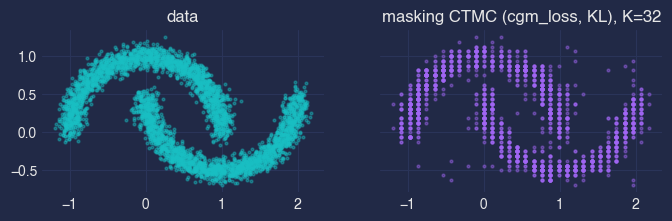

In [6]:
ctmc_field.eval()
ctmc = nami.GeneratorMatching(
    ctmc_field, nami.TauLeapingSampler(steps=50),
    parameterization=ctmc_param,
    base=nami.AllMask((2,), mask_index=ctmc_op.mask_index),
    event_shape=(2,),
)
with torch.no_grad():
    sample_tokens = ctmc().sample((2000,))
sample_coords = to_coords(sample_tokens)

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
axes[0].scatter(X[:, 0], X[:, 1], s=4, alpha=0.4)
axes[0].set_title("data")
axes[1].scatter(sample_coords[:, 0], sample_coords[:, 1], s=4, alpha=0.4, color="C2")
axes[1].set_title(f"masking CTMC (cgm_loss, KL), K={K}")
for a in axes:
    a.set_aspect("equal")
plt.show()

### Main takeaways

`cgm_loss` is the same call for both models; each operator declares how its parameters decompose and which Bregman divergence fits each component (`default_divergence`). You can override with `divergence=` — a single `BregmanDivergence` or a `{component: divergence}` mapping. Ito flow is squared-$L_2$ on the drift (an ODE; identical to flow-matching MSE). Masking CTMC is KL / cross-entropy on the simplex; the discreteness is visible as the grid quantisation, and the moons still emerge. visible as the grid quantisation, and the moons still emerge. The CTMC here supervises every*coordinate toward its clean token; a faithful masked-diffusion objective restricts the loss (and an $\alpha(t)$ weighting) to the masked positions (see the TODO hook in `nami/losses/cgm.py`).